In [1]:
!pip install transformers

In [2]:
import matplotlib.pyplot as plt
import cv2
import requests
import torch
from transformers import CLIPProcessor, CLIPModel

In [3]:
# 모델, 프로세서 불러오기 -> 사전학습 CLIP 불러오는 과정
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

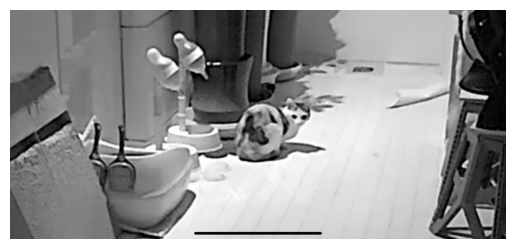

In [ ]:
# 사진 불러오고
image_path = "뒤돌아보는 고냥이.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
# 쿼리 지정
text_query = ["a very cute cat licking", "a cute cat sleeping", "a cat drinking water", "a cat eating food", "a cat looking back"]

In [ ]:
inputs = processor(text = text_query, images = image, return_tensors = "pt", padding = True)

outputs = model(**inputs)
logits_per_image = outputs.logits_per_image # image - text 사이의 유사도 score
probs = logits_per_image.softmax(dim = 1) # 유사도 score -> probability로 변환

pred_idx = torch.argmax(probs[0]).item()
pred_text = text_query[pred_idx]

print(f"The Model Predicted : {pred_text} !")

The Model Predicted : a cat eating food !
